In [5]:
import os
import glob
from collections import Counter
import joblib
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import hog
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [6]:
# load Data
IMG_SIZE = 128
DATA_PATH = "../Data/Scores"

In [8]:
# labels
paths, labels = [], []
for shape_name in sorted(os.listdir(DATA_PATH)):
    shape_path = os.path.join(DATA_PATH, shape_name)
    if not os.path.isdir(shape_path):
        continue
    for score in sorted(os.listdir(shape_path)):
        score_path = os.path.join(shape_path, score)
        if not os.path.isdir(score_path):
            continue
        label = f"{shape_name}_{score}"
        for ext in ("*.png", "*.jpg", "*.jpeg"):
            for p in glob.glob(os.path.join(score_path, ext)):
                paths.append(p)
                labels.append(label)

df = pd.DataFrame({"path": paths, "label": labels})
print("[INFO] Total files found:", len(df))

[INFO] Total files found: 4297


In [9]:
# Quick class distribution before any filtering
counts_before = Counter(df['label'])
print("[INFO] Classes before filtering (examples):", list(counts_before.items())[:8])

[INFO] Classes before filtering (examples): [('Circle_0', 5), ('Circle_2', 1), ('Circle_3', 112), ('Circle_4', 457), ('Diagonal_0', 4), ('Diagonal_3', 2), ('Diagonal_4', 70), ('Diagonal_5', 479)]


In [12]:
# Feature extraction (HOG + Hu moments + area)
def extract_features(path, img_size=IMG_SIZE):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (img_size, img_size))
    # HOG
    hog_feats = hog(img, orientations=9, pixels_per_cell=(8,8),
                    cells_per_block=(2,2), block_norm='L2-Hys', feature_vector=True)
    # Hu Moments
    moments = cv2.moments(img)
    hu_feats = cv2.HuMoments(moments).flatten()
    # Area
    area = [np.sum(img) / 255.0]
    return np.hstack([hog_feats, hu_feats, area])

print("[INFO] Extracting features (this may take a while)...")
features = []
for p in tqdm(df['path'], desc="Extracting"):
    features.append(extract_features(p))
X = np.vstack(features)
y_labels = np.array(df['label'])
print("[INFO] Feature matrix shape:", X.shape)

[INFO] Extracting features (this may take a while)...


Extracting: 100%|██████████| 4297/4297 [00:46<00:00, 92.88it/s]


[INFO] Feature matrix shape: (4297, 8108)


In [13]:
# Encode labels
le = LabelEncoder()
y = le.fit_transform(y_labels)
print("[INFO] Total classes:", len(le.classes_))

[INFO] Total classes: 34


In [15]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print("[INFO] Train size:", X_train.shape[0], "Test size:", X_test.shape[0])

[INFO] Train size: 3437 Test size: 860


In [16]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
# Train SVM
svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', random_state=42)
print("[INFO] Training SVM...")
svm_clf.fit(X_train_scaled, y_train)

[INFO] Training SVM...


SVC(class_weight='balanced', random_state=42)

In [21]:
# Evaluate & classification report
y_pred = svm_clf.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {acc:.4f}")

present_labels = np.unique(y_test)
target_names = [le.classes_[i] for i in present_labels]

report_dict = classification_report(
    y_test, y_pred,
    labels=present_labels,
    target_names=target_names,
    output_dict=True
)
report_df = pd.DataFrame(report_dict).transpose()

print(report_df)


Test Accuracy: 0.6791
                      precision    recall  f1-score    support
Circle_3               0.193548  0.230769  0.210526   26.00000
Circle_4               0.755319  0.710000  0.731959  100.00000
Diagonal_0             0.000000  0.000000  0.000000    1.00000
Diagonal_4             0.000000  0.000000  0.000000   15.00000
Diagonal_5             0.859813  0.920000  0.888889  100.00000
Overlapped circle_0    0.000000  0.000000  0.000000    1.00000
Overlapped circle_5    0.282051  0.323529  0.301370   34.00000
Overlapped circle_6    0.632184  0.647059  0.639535   85.00000
Overlapped pencils_0   0.000000  0.000000  0.000000    2.00000
Overlapped pencils_3   0.000000  0.000000  0.000000    1.00000
Overlapped pencils_4   0.000000  0.000000  0.000000    6.00000
Overlapped pencils_5   0.428571  0.387097  0.406780   31.00000
Overlapped pencils_6   0.596154  0.720930  0.652632   43.00000
Square_4               0.000000  0.000000  0.000000    9.00000
Square_5               0.922481 

/home/mahabur-alam/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mahabur-alam/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mahabur-alam/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

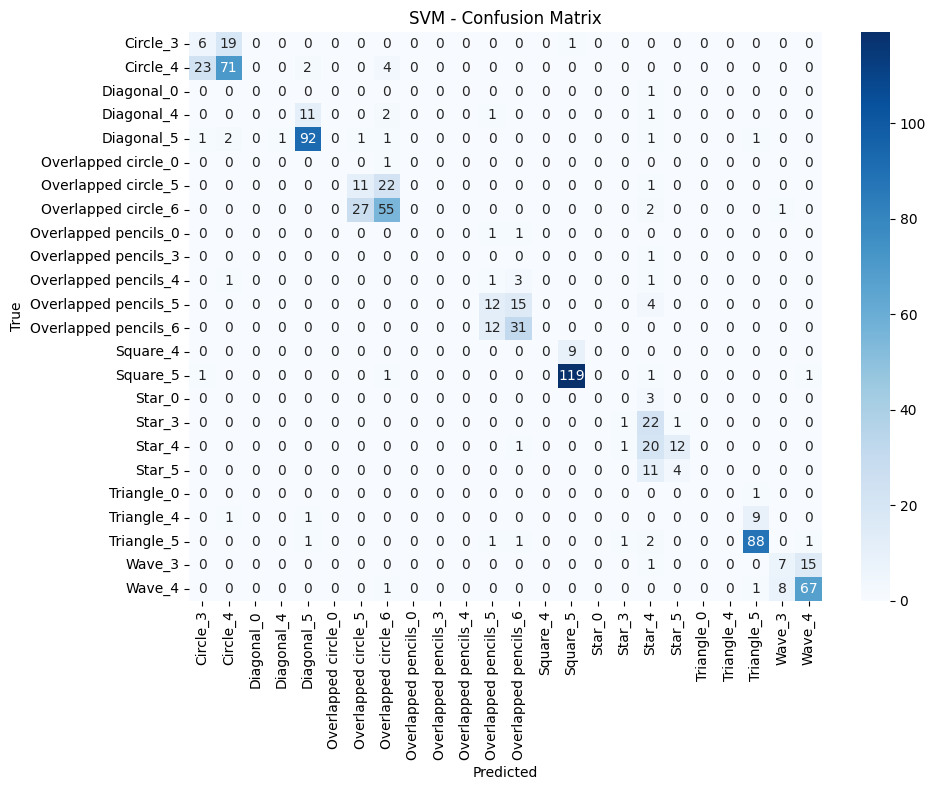

In [29]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=present_labels)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("SVM - Confusion Matrix")
plt.tight_layout()
plt.show()

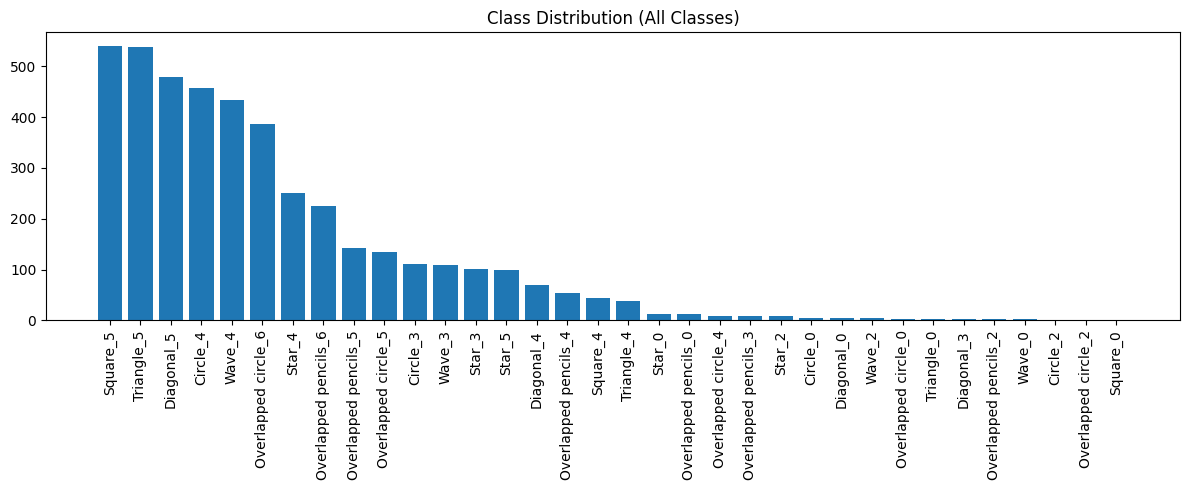

In [30]:
# Class distribution chart
plt.figure(figsize=(12,5))
labels_before, values_before = zip(*sorted(counts_before.items(), key=lambda x: -x[1]))
plt.bar(labels_before, values_before)
plt.xticks(rotation=90)
plt.title("Class Distribution (All Classes)")
plt.tight_layout()
plt.show()

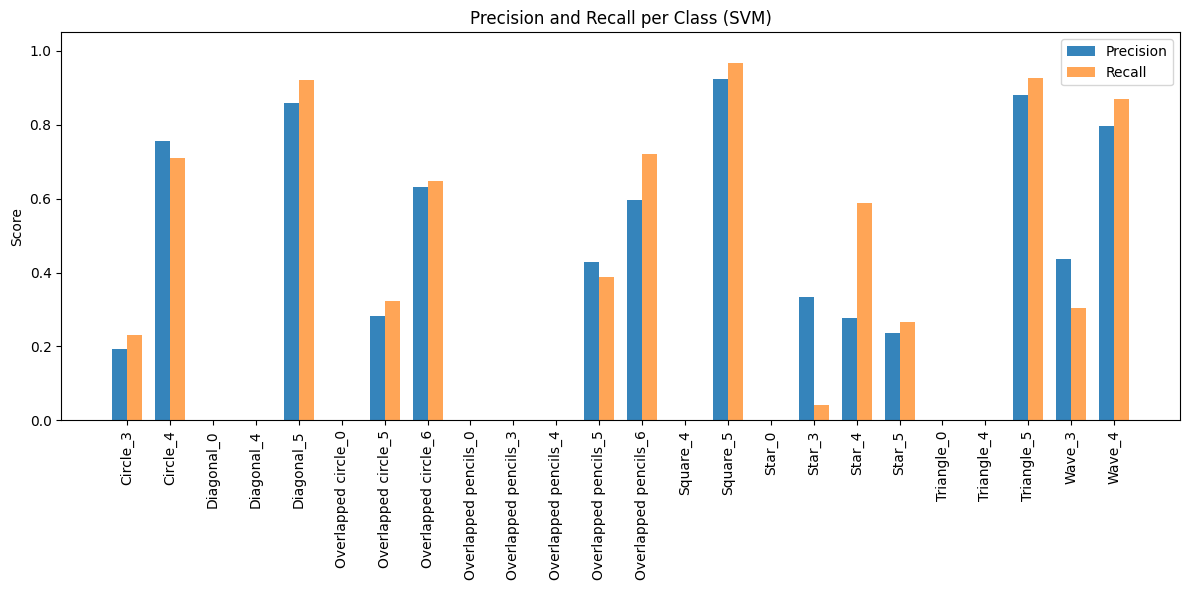

In [31]:
# Precision & Recall chart
class_rows = report_df.loc[target_names]

plt.figure(figsize=(12,6))
x = np.arange(len(class_rows))
width = 0.35
plt.bar(x - width/2, class_rows['precision'], width, label='Precision', alpha=0.9)
plt.bar(x + width/2, class_rows['recall'], width, label='Recall', alpha=0.7)
plt.xticks(x, class_rows.index, rotation=90)
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title("Precision and Recall per Class (SVM)")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# Save Model
SAVE_DIR = "./model_outputs/SVM"
os.makedirs(SAVE_DIR, exist_ok=True)

In [23]:
# Save model
model_path = os.path.join(SAVE_DIR, "svm_model.pkl")
joblib.dump(svm_clf, model_path)
print(f"[SAVED] SVM model → {model_path}")

[SAVED] SVM model → ./model_outputs/SVM/svm_model.pkl


In [24]:
# Save classification report
report_csv_path = os.path.join(SAVE_DIR, "classification_report.csv")
report_df.to_csv(report_csv_path, index=True)
print(f"[SAVED] Report (csv) → {report_csv_path}")

[SAVED] Report (csv) → ./model_outputs/SVM/classification_report.csv


In [28]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=present_labels)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("SVM - Confusion Matrix")
plt.tight_layout()
cm_path = os.path.join(SAVE_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=150)
plt.close()
print(f"[SAVED] Confusion Matrix → {cm_path}")

[SAVED] Confusion Matrix → ./model_outputs/SVM/confusion_matrix.png


In [27]:
# Class distribution chart
plt.figure(figsize=(12,5))
labels_before, values_before = zip(*sorted(counts_before.items(), key=lambda x: -x[1]))
plt.bar(labels_before, values_before)
plt.xticks(rotation=90)
plt.title("Class Distribution (All Classes)")
plt.tight_layout()
dist_path = os.path.join(SAVE_DIR, "class_distribution.png")
plt.savefig(dist_path, dpi=150)
plt.close()
print(f"[SAVED] Class Distribution → {dist_path}")

[SAVED] Class Distribution → ./model_outputs/SVM/class_distribution.png


In [26]:
# Precision & Recall chart save
class_rows = report_df.loc[target_names]

plt.figure(figsize=(12,6))
x = np.arange(len(class_rows))
width = 0.35
plt.bar(x - width/2, class_rows['precision'], width, label='Precision', alpha=0.9)
plt.bar(x + width/2, class_rows['recall'], width, label='Recall', alpha=0.7)
plt.xticks(x, class_rows.index, rotation=90)
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title("Precision and Recall per Class (SVM)")
plt.legend()
plt.tight_layout()
pr_path = os.path.join(SAVE_DIR, "precision_recall_per_class.png")
plt.savefig(pr_path, dpi=150)
plt.close()
print(f"[SAVED] Precision/Recall chart → {pr_path}")

[SAVED] Precision/Recall chart → ./model_outputs/SVM/precision_recall_per_class.png
